# Behavioral Analysis
## - evidence of conflicting value maps in States A and B but not C

In [73]:
import h5_utilities_module as h5u
import numpy as np
import pandas as pd
import pingouin as pg
from tqdm import tqdm
from matplotlib import pyplot as plt
import statsmodels.formula.api as smf
import matplotlib.gridspec as gridspec
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [3]:
# define the directory where the files live
data_dir = r'C:/Users/thome/Documents/PYTHON/OFC-CdN 3 state self control/files_for_decoder/'
data_files = h5u.find_h5_files(data_dir)

In [20]:
# functions
def calculate_mean_and_interval(data, type='sem', num_samples=1000, alpha=0.05):
    """
    Calculate mean and either SEM or bootstrapped CI for input array, disregarding NaN values.
    Works with both 1D and 2D arrays.
    """
    # Ensure data is 2D
    data = np.asarray(data)
    if data.ndim == 1:
        data = data.reshape(-1, 1)
    
    nan_mask = ~np.isnan(data)
    nanmean_result = np.nanmean(data, axis=0)
    n_valid_values = np.sum(nan_mask, axis=0)
    
    if type == 'sem':
        nanstd_result = np.nanstd(data, axis=0)
        interval = nanstd_result / np.sqrt(n_valid_values)
        
    elif type == 'percentile':
        interval = np.nanmean(np.array([
            np.abs(nanmean_result - np.nanpercentile(data, 5, axis=0)),
            np.abs(nanmean_result - np.nanpercentile(data, 95, axis=0))
        ]))
        
    elif type == 'bootstrap':
        n_rows = data.shape[0]
        n_cols = data.shape[1]
        bootstrap_means = np.zeros((num_samples, n_cols))

        for col in range(n_cols):
            valid_data = data[:, col][nan_mask[:, col]]
            if len(valid_data) > 0:
                bootstrap_samples = np.random.choice(valid_data, size=(num_samples, n_rows), replace=True)
                bootstrap_means[:, col] = np.nanmean(bootstrap_samples, axis=1)
            else:
                bootstrap_means[:, col] = np.nan

        ci_lower = np.percentile(bootstrap_means, 100 * (alpha / 2), axis=0)
        ci_upper = np.percentile(bootstrap_means, 100 * (1 - alpha / 2), axis=0)
        interval = np.nanmean([
            abs(bootstrap_means - ci_lower),
            abs(bootstrap_means - ci_upper)
        ], axis=0)
        interval = np.nanmean(interval, axis=0)

    else:
        raise ValueError("Invalid 'type' argument. Use 'sem', 'percentile', or 'bootstrap'.")
    
    # Properly handle scalar output
    if data.shape[1] == 1:
        nanmean_result = float(nanmean_result[0])  # explicitly convert to float scalar
        if not np.isscalar(interval):
            interval = float(interval[0])  # explicitly convert to float scalar
    
    return nanmean_result, interval

def check_vif(formula_vars, data):
    X = data[formula_vars].dropna()
    return [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

In [74]:
# loop over the files and accumulate the behavioral data

# initialize a dataframe
bhv = pd.DataFrame()

for this_file in tqdm(data_files):
    
    # pull this file's behavior
    f_data = pd.read_hdf(this_file, key='bhv')

    # Append the data to the accumulated dataframe
    bhv = pd.concat([bhv, f_data], ignore_index=True)


100%|██████████| 8/8 [00:00<00:00, 100.75it/s]


In [77]:
# create indices to separately analyze each monkey
k_ix = bhv['fname'].str.contains('K')
d_ix = bhv['fname'].str.contains('D')
bhv['subject'] = np.where(k_ix, 0, 1)
bhv['delta_val'] = bhv['r_val'] - bhv['l_val']

In [7]:
# get overall choice accuracies
k_acc = bhv['picked_best'].loc[k_ix].mean()
d_acc = bhv['picked_best'].loc[d_ix].mean()

print('subject K accuracy: ' + str(k_acc*100))
print('subject D accuracy: ' + str(d_acc*100))

subject K accuracy: 98.81312543635094
subject D accuracy: 97.78645833333334


In [8]:
# find the identities of the value differences
val_diff = bhv['l_val'] - bhv['r_val']
val_diff_ids = np.unique(val_diff[~np.isnan(val_diff)])
# find the trials where the monkey picked the left option

picked_left = (bhv['side'] == -1).to_numpy().astype(int).reshape((-1, 1))
rt = bhv['rt'].values.reshape((-1,1))
n_sacc = bhv['n_sacc'].values.reshape(-1,1)

# we're only going to assess the free choices
free_ix = bhv['forced'] == 0

# initialize arrays to accumulate results into
# choice accuracy
choice_acc_mean = np.zeros((3, len(val_diff_ids), 2)) # 3 states, n_val_diffs, 2 monkeys
choice_acc_ci = np.zeros((3, len(val_diff_ids), 2)) # 3 states, n_val_diffs, 2 monkeys

# choice reaction time
choice_rt_mean = np.zeros((3, len(val_diff_ids), 2)) # 3 states, n_val_diffs, 2 monkeys
choice_rt_ci = np.zeros((3, len(val_diff_ids), 2)) # 3 states, n_val_diffs, 2 monkeys


# loop over the val_diff_ids and get the mean for each value difference and state
for v_num, v_id in enumerate(val_diff_ids):

    # find the trials associated with this value difference
    v_ix = val_diff == v_id

    # take the means and 95% CIs
    choice_acc_mean[0, v_num, 0], choice_acc_ci[0, v_num, 0] = calculate_mean_and_interval(picked_left[free_ix & v_ix & (bhv['state'] == 1) & k_ix], 'bootstrap')
    choice_acc_mean[1, v_num, 0], choice_acc_ci[1, v_num, 0] = calculate_mean_and_interval(picked_left[free_ix & v_ix & (bhv['state'] == 2) & k_ix], 'bootstrap')
    choice_acc_mean[2, v_num, 0], choice_acc_ci[2, v_num, 0] = calculate_mean_and_interval(picked_left[free_ix & v_ix & (bhv['state'] == 3) & k_ix], 'bootstrap')

    choice_acc_mean[0, v_num, 1], choice_acc_ci[0, v_num, 1] = calculate_mean_and_interval(picked_left[free_ix & v_ix & (bhv['state'] == 1) & d_ix], 'bootstrap')
    choice_acc_mean[1, v_num, 1], choice_acc_ci[1, v_num, 1] = calculate_mean_and_interval(picked_left[free_ix & v_ix & (bhv['state'] == 2) & d_ix], 'bootstrap')
    choice_acc_mean[2, v_num, 1], choice_acc_ci[2, v_num, 1] = calculate_mean_and_interval(picked_left[free_ix & v_ix & (bhv['state'] == 3) & d_ix], 'bootstrap')

    choice_rt_mean[0, v_num, 0], choice_rt_ci[0, v_num, 0] = calculate_mean_and_interval(rt[free_ix & v_ix & (bhv['state'] == 1) & k_ix], 'bootstrap')
    choice_rt_mean[1, v_num, 0], choice_rt_ci[1, v_num, 0] = calculate_mean_and_interval(rt[free_ix & v_ix & (bhv['state'] == 2) & k_ix], 'bootstrap')
    choice_rt_mean[2, v_num, 0], choice_rt_ci[2, v_num, 0] = calculate_mean_and_interval(rt[free_ix & v_ix & (bhv['state'] == 3) & k_ix], 'bootstrap')

    choice_rt_mean[0, v_num, 1], choice_rt_ci[0, v_num, 1] = calculate_mean_and_interval(rt[free_ix & v_ix & (bhv['state'] == 1) & d_ix], 'bootstrap')
    choice_rt_mean[1, v_num, 1], choice_rt_ci[1, v_num, 1] = calculate_mean_and_interval(rt[free_ix & v_ix & (bhv['state'] == 2) & d_ix], 'bootstrap')
    choice_rt_mean[2, v_num, 1], choice_rt_ci[2, v_num, 1] = calculate_mean_and_interval(rt[free_ix & v_ix & (bhv['state'] == 3) & d_ix], 'bootstrap')

In [9]:
# find the value of the item the animals first saccaded towards on double-take trials
single_take_ix = (bhv['n_sacc'] == 1) & free_ix
double_take_ix = (bhv['n_sacc'] == 2) & free_ix

# initialize an array to accumulate results into
first_sacc_mean = np.zeros((4, 2)) 
first_sacc_ci = np.zeros((4, 2)) 


# get the values fixated on double takes
sacc1_vals = bhv['sacc1_val'].values.reshape(-1,1)

# calculate means and confidence intervals
first_sacc_mean[0,0], first_sacc_ci[0,0] = calculate_mean_and_interval(sacc1_vals[single_take_ix & k_ix & (bhv['state']<3)], 'bootstrap')
first_sacc_mean[1,0], first_sacc_ci[1,0] = calculate_mean_and_interval(sacc1_vals[double_take_ix & k_ix & (bhv['state']<3)], 'bootstrap')
first_sacc_mean[2,0], first_sacc_ci[2,0] = calculate_mean_and_interval(sacc1_vals[single_take_ix & k_ix & (bhv['state']==3)], 'bootstrap')
first_sacc_mean[3,0], first_sacc_ci[3,0] = calculate_mean_and_interval(sacc1_vals[double_take_ix & k_ix & (bhv['state']==3)], 'bootstrap')


first_sacc_mean[0,1], first_sacc_ci[0,1] = calculate_mean_and_interval(sacc1_vals[single_take_ix & d_ix & (bhv['state']<3)], 'bootstrap')
first_sacc_mean[1,1], first_sacc_ci[1,1] = calculate_mean_and_interval(sacc1_vals[double_take_ix & d_ix & (bhv['state']<3)], 'bootstrap')
first_sacc_mean[2,1], first_sacc_ci[2,1] = calculate_mean_and_interval(sacc1_vals[single_take_ix & d_ix & (bhv['state']==3)], 'bootstrap')
first_sacc_mean[3,1], first_sacc_ci[3,1] = calculate_mean_and_interval(sacc1_vals[double_take_ix & d_ix & (bhv['state']==3)], 'bootstrap')


(0.0, 3.0)

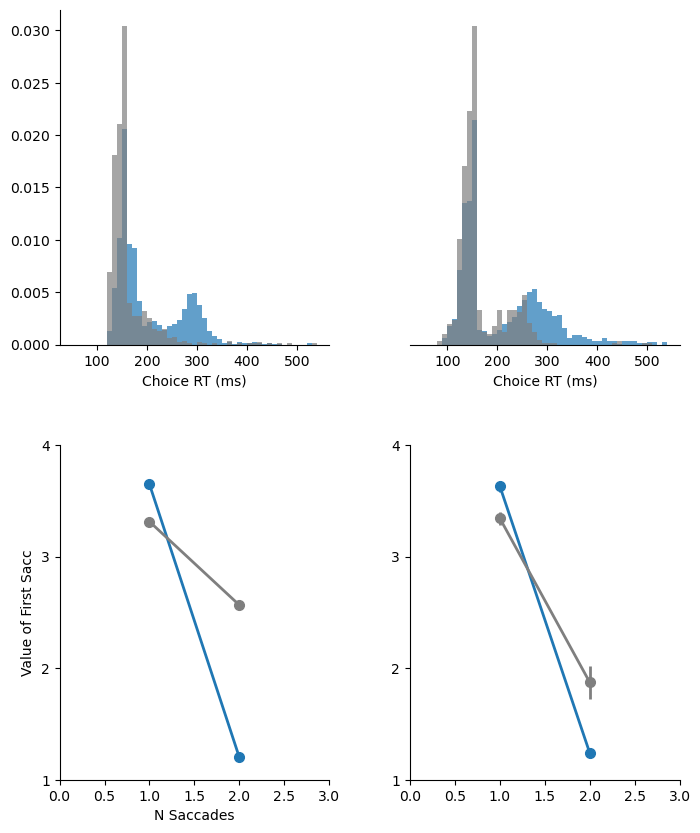

In [60]:
# now let's plot

fig, ax = plt.subplots(2, 2, figsize=(8,10))
# Adjust space between subplots
fig.subplots_adjust(wspace=0.3, hspace=.3)  # add some white space between the plots

# define bins for the histogram
bins = np.arange(50, 550, 10)

# plot King's data

# choice RT histograms
ax[0,0].hist(bhv['rt'].loc[k_ix & (bhv['state'] <3) & free_ix], bins=bins, density='probability', alpha = .7, color='tab:blue')
ax[0,0].hist(bhv['rt'].loc[k_ix & (bhv['state'] == 3) & free_ix], bins=bins, density='probability', alpha = .7, color='tab:gray')
ax[0,0].set_xlabel('Choice RT (ms)')
ax[0,0].spines['right'].set_visible(False)
ax[0,0].spines['top'].set_visible(False)
ax[0,0].set_xticks((100, 200, 300, 400, 500))


# value of first saccade by state and number of saccades
ax[1,0].errorbar([1,2], first_sacc_mean[0:2, 0], first_sacc_ci[0:2, 0], color='tab:blue', marker='o', ms = 7, lw=2)
ax[1,0].errorbar([1,2], first_sacc_mean[2:4, 0], first_sacc_ci[0:2, 0], color='tab:gray', marker='o', ms = 7, lw=2)
ax[1,0].spines['right'].set_visible(False)
ax[1,0].spines['top'].set_visible(False)
ax[1,0].set_xlabel('N Saccades')
ax[1,0].set_xlim((0,3))
ax[1,0].set_ylabel('Value of First Sacc')
ax[1,0].set_ylim((1, 4))
ax[1,0].set_yticks((1, 2, 3, 4))




# Don

# choice RT histograms
ax[0,1].hist(bhv['rt'].loc[d_ix & (bhv['state'] <3) & free_ix], bins=bins, density='probability', alpha = .7, color='tab:blue')
ax[0,1].hist(bhv['rt'].loc[d_ix & (bhv['state'] == 3) & free_ix], bins=bins, density='probability', alpha = .7, color='tab:gray')
ax[0,1].set_xlabel('Choice RT (ms)')
ax[0,1].spines['right'].set_visible(False)
ax[0,1].spines['left'].set_visible(False)
ax[0,1].spines['top'].set_visible(False)
ax[0,1].set_yticks(())
ax[0,1].set_xticks((100, 200, 300, 400, 500))

# value of first saccade by state and number of saccades
ax[1,1].errorbar([1,2], first_sacc_mean[0:2, 1], first_sacc_ci[0:2, 1], color='tab:blue', marker='o', ms = 7, lw = 2)
ax[1,1].errorbar([1,2], first_sacc_mean[2:4, 1], first_sacc_ci[2:4, 1], color='tab:gray', marker='o', ms = 7, lw = 2)
ax[1,1].spines['right'].set_visible(False)
ax[1,1].spines['top'].set_visible(False)
ax[1,1].set_ylim((1, 4))
ax[1,1].set_yticks((1, 2, 3, 4))
ax[1,1].set_xlim((0,3))

# save the figure as a png
#plt.savefig("DTs_and_vals.svg")


In [62]:
# build the dataframe
sacc_df = pd.DataFrame()

sacc_df['session'] = np.concatenate((
    bhv['fname'].loc[single_take_ix & (bhv['state']<3)].values,
    bhv['fname'].loc[double_take_ix & (bhv['state']<3)].values,
    bhv['fname'].loc[single_take_ix & (bhv['state']==3)].values,
    bhv['fname'].loc[double_take_ix & (bhv['state']==3)].values
), axis=0).flatten()

monkey_ix = np.concatenate((
    k_ix[single_take_ix & (bhv['state']<3)],
    k_ix[double_take_ix & (bhv['state']<3)],
    k_ix[single_take_ix & (bhv['state']==3)],
    k_ix[double_take_ix & (bhv['state']==3)]
), axis=0).flatten() > 0

sacc_df['sacc_val'] = np.concatenate((
    sacc1_vals[single_take_ix & (bhv['state']<3)],
    sacc1_vals[double_take_ix & (bhv['state']<3)],
    sacc1_vals[single_take_ix & (bhv['state']==3)],
    sacc1_vals[double_take_ix & (bhv['state']==3)]
), axis=0).flatten().astype(int)

sacc_df['n_sacc'] = np.concatenate((
    np.zeros(np.sum(single_take_ix & (bhv['state']<3))),
    np.ones(np.sum(double_take_ix & (bhv['state']<3))),
    np.zeros(np.sum(single_take_ix & (bhv['state']==3))),
    np.ones(np.sum(double_take_ix & (bhv['state']==3)))
), axis=0)

sacc_df['state'] = np.concatenate((
    np.zeros(np.sum(single_take_ix & (bhv['state']<3))),
    np.zeros(np.sum(double_take_ix & (bhv['state']<3))),
    np.ones(np.sum(single_take_ix & (bhv['state']==3))),
    np.ones(np.sum(double_take_ix & (bhv['state']==3)))
), axis=0)

# fit mixed effects models with session as random effect, separately per subject
k_data = sacc_df.loc[monkey_ix == 1].copy()
d_data = sacc_df.loc[monkey_ix == 0].copy()

k_sacc_model = smf.mixedlm(
    'sacc_val ~ n_sacc * state',
    data=k_data,
    groups=k_data['session']
).fit()

d_sacc_model = smf.mixedlm(
    'sacc_val ~ n_sacc * state',
    data=d_data,
    groups=d_data['session']
).fit()

print('Subject K')
print(k_sacc_model.summary())
print('\nSubject D')
print(d_sacc_model.summary())

Subject K
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: sacc_val  
No. Observations: 2505    Method:             REML      
No. Groups:       4       Scale:              0.4029    
Min. group size:  563     Log-Likelihood:     -2424.3825
Max. group size:  664     Converged:          Yes       
Mean group size:  626.2                                 
--------------------------------------------------------
             Coef.  Std.Err.    z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept     3.647    0.021 170.624 0.000  3.605  3.689
n_sacc       -2.447    0.033 -73.961 0.000 -2.512 -2.382
state        -0.335    0.029 -11.431 0.000 -0.392 -0.277
n_sacc:state  1.697    0.138  12.270 0.000  1.426  1.968
Group Var     0.000    0.001                            


Subject D
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: sacc_val  
No. Observations: 2149    Met

c:\Users\thome\anaconda3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\thome\anaconda3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [122]:
bhv['chose_right'] = (bhv['side'] == 1).astype(int)

trials2use = bhv['rt'] < 500

k_val_model_s3 = smf.logit(
    'chose_right ~ delta_val + C(state, Sum)',
    data=bhv.loc[k_ix & free_ix & trials2use]
).fit(disp=0)

d_val_model = smf.logit(
    'chose_right ~ delta_val + C(state, Sum)',
    data=bhv.loc[d_ix & free_ix & trials2use]
).fit(disp=0)

print('Subject K')
print(k_val_model.summary())
print('\nSubject D')
print(d_val_model.summary())

Subject K
                           Logit Regression Results                           
Dep. Variable:            chose_right   No. Observations:                 2586
Model:                          Logit   Df Residuals:                     2582
Method:                           MLE   Df Model:                            3
Date:                Tue, 10 Mar 2026   Pseudo R-squ.:                  0.8688
Time:                        13:47:17   Log-Likelihood:                -235.10
converged:                       True   LL-Null:                       -1792.3
Covariance Type:            nonrobust   LLR p-value:                     0.000
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                0.0901      0.137      0.655      0.512      -0.179       0.360
C(state, Sum)[S.1.0]    -0.0606      0.193     -0.314      0.753      -0.439       0.318
C(

In [120]:
print(k_val_model.params.index.tolist())

['Intercept', 'C(state, Sum)[S.1.0]', 'C(state, Sum)[S.2.0]', 'delta_val']


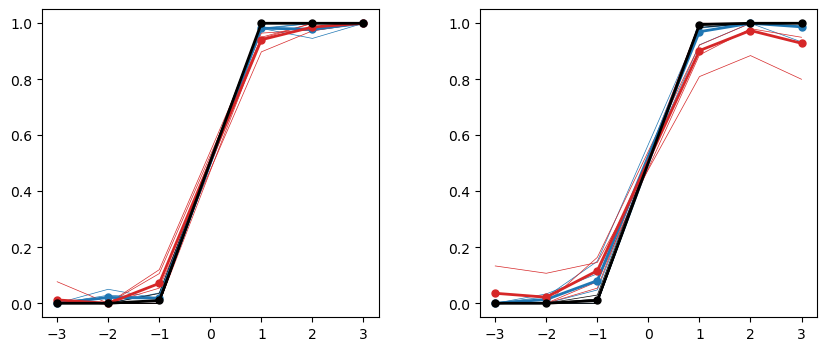

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.subplots_adjust(wspace=0.3)
state_colors = {1: 'tab:red', 2: 'tab:blue', 3: 'tab:green'}
state_labels = {1: 'State A', 2: 'State B', 3: 'State C'}
val_diff_levels = [-3, -2, -1, 1, 2, 3]
subs = np.unique(bhv['subject'])
choose_right = (bhv['side'] == 1).values

# loop over monkeys
for s_ix, s in enumerate(subs):
    this_monkey_sessions = np.unique(bhv['fname'].loc[bhv['subject'] == s])

    # pre-allocate arrays for this subject's grand mean
    grand_state_means = np.zeros(shape = (3, len(val_diff_levels)))

    # pre-allocate arrays for the session means
    sessions_state_means = np.zeros(shape = (3, len(val_diff_levels), len(this_monkey_sessions)))


    # now get the grand mean results for this subject
    # loop over the states
    for state_ix, this_state in enumerate(np.unique(bhv['state'])):

        # now loop over the value differences
        for v_ix, delta_val in enumerate(val_diff_levels):

            # index the trials which correspond to this state-value-subject combination
            this_state_val = (bhv['subject'] == s) & (bhv['state'] == this_state) & (bhv['delta_val'] == delta_val) & free_ix & (bhv['rt'] < 500)
            grand_state_means[state_ix, v_ix] = np.nanmean(choose_right[this_state_val])


            # now get the means for each session
            for session_ix, this_session in enumerate(this_monkey_sessions):

                this_session_ix = bhv['fname'] == this_session

                sessions_state_means[state_ix, v_ix, session_ix] = np.nanmean(choose_right[this_state_val & this_session_ix])

    # now plot for this monkey
    axes[s_ix].plot(val_diff_levels, sessions_state_means[0,:,:], color = 'tab:blue', lw = .5)
    axes[s_ix].plot(val_diff_levels, sessions_state_means[1,:,:], color = 'tab:red', lw = .5)
    axes[s_ix].plot(val_diff_levels, sessions_state_means[2,:,:], color = 'black', lw = .5)


    axes[s_ix].plot(val_diff_levels, grand_state_means[0, :], color = 'tab:blue', lw = 2, marker='o', markersize = 5)
    axes[s_ix].plot(val_diff_levels, grand_state_means[1, :], color = 'tab:red', lw = 2, marker='o', markersize = 5)
    axes[s_ix].plot(val_diff_levels, grand_state_means[2, :], color = 'black', lw = 2, marker='o', markersize = 5)

# now let's save the plot
#fig.savefig('choice-accuracy-by-state.svg')





In [ ]:
# find the liklihood of a double-take as a function of each left/right choice

val_ids = np.unique(bhv['l_val'].loc[~np.isnan(bhv['l_val'])])
n_vals = len(val_ids)

state_AB_ix = bhv['state'] < 3
state_C_ix = bhv['state'] == 3

dt = bhv['n_sacc'] > 1

pDT_by_val_and_state = np.zeros((n_vals, n_vals, 2, 2)) # each left-right value combination, 2 states, 2 monkeys
pDT_by_val_and_state[:] = np.nan

# loop over each combination of left and right values
for l_ix, l_val in enumerate(val_ids):
    for r_ix, r_val in enumerate(val_ids):

        val_combi_ix = (bhv['l_val'] == l_val) & (bhv['r_val'] == r_val)

        if r_val != l_val:
            pDT_by_val_and_state[l_ix, r_ix, 0, 0] = np.nanmean(dt[val_combi_ix & free_ix & k_ix & state_AB_ix], axis=0)
            pDT_by_val_and_state[l_ix, r_ix, 1, 0] = np.nanmean(dt[val_combi_ix & free_ix & k_ix & state_C_ix], axis=0)

            pDT_by_val_and_state[l_ix, r_ix, 0, 1] = np.nanmean(dt[val_combi_ix & free_ix & d_ix & state_AB_ix], axis=0)
            pDT_by_val_and_state[l_ix, r_ix, 1, 1] = np.nanmean(dt[val_combi_ix & free_ix & d_ix & state_C_ix], axis=0)

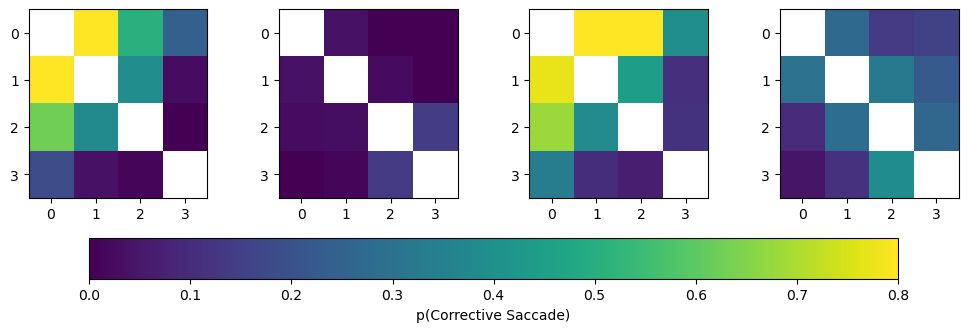

In [14]:
# show mean RTs and mean n_sacc for all trial conditions separately
fig, ax = plt.subplots(1, 4, figsize=(12, 3.5))
fig.subplots_adjust(wspace=0.4, hspace=.4)  # add some white space between the plots
p_min = 0
p_max = .8

# organized as:
# subject as column pairs (leftmost is subj K's RTs, then K's n_sacc, then D's RTs, then D's n_sacc)
im0 = ax[0].imshow(pDT_by_val_and_state[:,:,0, 0], aspect='auto', vmin=p_min, vmax=p_max)
im1 = ax[1].imshow(pDT_by_val_and_state[:,:,1, 0], aspect='auto', vmin=p_min, vmax=p_max)
im2 = ax[2].imshow(pDT_by_val_and_state[:,:,0, 1], aspect='auto', vmin=p_min, vmax=p_max)
im3 = ax[3].imshow(pDT_by_val_and_state[:,:,1, 1], aspect='auto', vmin=p_min, vmax=p_max)

# Add a single colorbar shared for all RT plots
fig.colorbar(im0, ax=ax, orientation='horizontal', label='p(Corrective Saccade)')

#plt.show()
#plt.savefig("probDT_by_cond.svg")




5. The assumption that low conflict between value schemas (involving items 2 and 3) elicited no corrective saccades whereas high conflict (involving items 1 and 4) elicited corrective saccades should be tested formally. This could be done by regressing the likelihood of a corrective saccade (and, separately, RT) on different critical variables: relative and absolute value difference within set, 'conflict' as defined as the difference in the value of an item in current state with that in the alternative state (this could perhaps be defined for each option, or summed together across the two options if the regressors are too highly correlated). This analysis is important for a complete understanding of the factors that drove corrective saccades, which is necessary for interpreting neuronal responses and supporting the conclusion that "corrective saccades reflect the conflict driven recruitment of cognitive control."

In [29]:
# fit models assessing why corrective saccades occur
# use all free choice trials across all states
all_free_ix = free_ix
reg_df = bhv.loc[all_free_ix].copy()

# create indices to keep track of the animal
k_ix_reg = reg_df['fname'].str.contains('K')
d_ix_reg = reg_df['fname'].str.contains('D')

# create indices for the states
stateAB_ix = reg_df['state'] < 3
stateC_ix = reg_df['state'] == 3

# dummy code state: 1 for states A and B, -1 for state C
reg_df['state_AB'] = np.where(reg_df['state'] < 3, 1, -1)

# define the counterfactual values of the options (only meaningful for states A and B)
reg_df['l_val_counter'] = np.where(reg_df['state'] < 3, 5 - reg_df['l_val'], np.nan)
reg_df['r_val_counter'] = np.where(reg_df['state'] < 3, 5 - reg_df['r_val'], np.nan)

# define cross-state conflict such that larger numbers indicate the counterfactual value is better
reg_df['conflict_L'] = np.where(reg_df['state'] < 3, reg_df['l_val_counter'] - reg_df['l_val'], 0)
reg_df['conflict_R'] = np.where(reg_df['state'] < 3, reg_df['r_val_counter'] - reg_df['r_val'], 0)

# define summary conflict terms and outcome variables
reg_df['real_val_diff'] = np.abs(reg_df['l_val'] - reg_df['r_val'])
reg_df['conflict_sum']  = reg_df['conflict_L'] + reg_df['conflict_R']
# candidate alternative predictors for model comparison
reg_df['max_val'] = reg_df[['l_val', 'r_val']].max(axis=1)
reg_df['sum_val'] = reg_df['l_val'] + reg_df['r_val']
reg_df['AB_val_diff']   = np.where(reg_df['state_AB'] ==  1, reg_df['real_val_diff'], 0)
reg_df['C_val_diff']    = np.where(reg_df['state_AB'] == -1, reg_df['real_val_diff'], 0)
reg_df['corrective_sacc'] = (reg_df['n_sacc'] > 1).astype(int)

reg_df['subject'] = np.where(reg_df['fname'].str.contains('K'), 'K', 'D')


In [30]:
# check the variance inflation factors of possible candidate models
# - can we include real_val_diff and max_val in the same model?
# ANSWER - no

model_comparisons = [
    ('conflict + val_diff', ['conflict_sum', 'real_val_diff']),
    ('conflict + max_val', ['conflict_sum', 'max_val']),
    ('conflict + val_diff + max_val', ['conflict_sum', 'real_val_diff', 'max_val']),
    ('val_diff + max_val', ['real_val_diff', 'max_val']),
]

vif_rows = []
for subj, ix in zip(['K', 'D'], [k_ix_reg, d_ix_reg]):
    data = reg_df.loc[ix & stateAB_ix]
    for model_name, vars in model_comparisons:
        vifs = check_vif(vars, data)
        for var, vif in zip(vars, vifs):
            vif_rows.append({
                'Subject': subj,
                'Model': model_name,
                'Predictor': var,
                'VIF': round(vif, 2)
            })

vif_df = pd.DataFrame(vif_rows)
print(vif_df.to_string(index=False))

Subject                         Model     Predictor   VIF
      K           conflict + val_diff  conflict_sum  1.00
      K           conflict + val_diff real_val_diff  1.00
      K            conflict + max_val  conflict_sum  1.03
      K            conflict + max_val       max_val  1.03
      K conflict + val_diff + max_val  conflict_sum  1.37
      K conflict + val_diff + max_val real_val_diff 10.75
      K conflict + val_diff + max_val       max_val 11.12
      K            val_diff + max_val real_val_diff  8.10
      K            val_diff + max_val       max_val  8.10
      D           conflict + val_diff  conflict_sum  1.00
      D           conflict + val_diff real_val_diff  1.00
      D            conflict + max_val  conflict_sum  1.03
      D            conflict + max_val       max_val  1.03
      D conflict + val_diff + max_val  conflict_sum  1.40
      D conflict + val_diff + max_val real_val_diff 11.22
      D conflict + val_diff + max_val       max_val 11.55
      D       

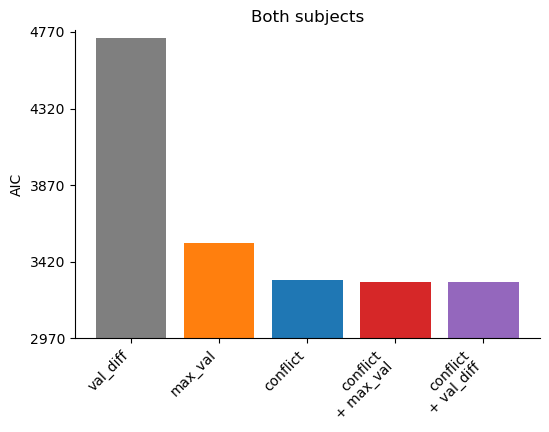

In [ ]:
# Does conflict improve prediction of corrective saccades over and above other value parameters?
data_AB = reg_df.loc[stateAB_ix].copy()

formulas = {
    'val_diff':             'corrective_sacc ~ real_val_diff + C(subject)',
    'max_val':              'corrective_sacc ~ max_val + C(subject)',
    'conflict':             'corrective_sacc ~ conflict_sum + C(subject)',
    'conflict\n+ val_diff': 'corrective_sacc ~ conflict_sum + real_val_diff + C(subject)',
    'conflict\n+ max_val':  'corrective_sacc ~ conflict_sum + max_val + C(subject)',
}

models = {}
aics = {}
for label, formula in formulas.items():
    model = smf.logit(formula, data=data_AB).fit(disp=0)
    models[label] = model
    aics[label] = model.aic

# plot
model_labels = list(formulas.keys())
colors = ['tab:gray', 'tab:orange', 'tab:blue', 'tab:purple', 'tab:red']
vals = [aics[label] for label in model_labels]

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
order = np.argsort(vals)[::-1]
sorted_labels = [model_labels[j] for j in order]
sorted_vals = [vals[j] for j in order]
sorted_colors = [colors[j] for j in order]
ax.bar(sorted_labels, sorted_vals, color=sorted_colors)
ymin = min(sorted_vals) * 0.9
ymax = max(sorted_vals) * 1.01
tick_min = int(np.ceil(ymin / 10) * 10)
tick_max = int(np.floor(ymax / 10) * 10)
yticks = np.round(np.linspace(tick_min, tick_max, 5) / 10) * 10
ax.set_ylim(ymin, ymax)
ax.set_yticks(yticks)
ax.set_title('Both subjects')
ax.set_ylabel('AIC')
ax.set_xticks(range(len(model_labels)))
ax.set_xticklabels(sorted_labels, rotation=45, ha='right')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
#plt.savefig('model-comparion-AICs.svg')

In [ ]:
data_all = reg_df.loc[free_ix].copy()

# standardize predictors before computing interaction
data_all['val_diff_z'] = (data_all['real_val_diff'] - data_all['real_val_diff'].mean()) / data_all['real_val_diff'].std()
data_all['state_AB_z'] = (data_all['state_AB'] - data_all['state_AB'].mean()) / data_all['state_AB'].std()

# fit the model with interaction
model_partb = smf.logit('corrective_sacc ~ val_diff_z * state_AB_z + C(subject)', 
                         data=data_all).fit(disp=0)
print(model_partb.summary())

                           Logit Regression Results                           
Dep. Variable:        corrective_sacc   No. Observations:                 5306
Model:                          Logit   Df Residuals:                     5301
Method:                           MLE   Df Model:                            4
Date:                Tue, 10 Mar 2026   Pseudo R-squ.:                 0.09775
Time:                        09:30:58   Log-Likelihood:                -2948.6
converged:                       True   LL-Null:                       -3268.1
Covariance Type:            nonrobust   LLR p-value:                5.957e-137
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                -0.6719      0.046    -14.497      0.000      -0.763      -0.581
C(subject)[T.K]          -0.6249      0.063     -9.868      0.000      -0.749      -0.501
val_diff

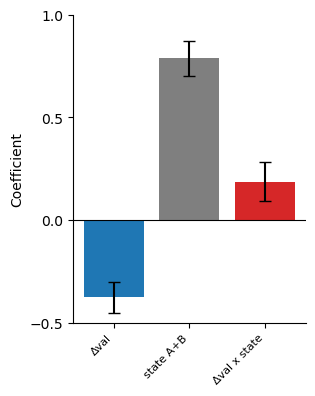

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(3, 4))

# extract coefficients and CIs, excluding nuisance terms
terms = ['val_diff_z', 'state_AB_z', 'val_diff_z:state_AB_z']
labels_e = ['Δval', 'state A+B', 'Δval x state']
colors_e = ['tab:blue', 'tab:gray', 'tab:red']

coefs = [model_partb.params[t] for t in terms]
ci_low = [model_partb.conf_int().loc[t, 0] for t in terms]
ci_high = [model_partb.conf_int().loc[t, 1] for t in terms]
yerr_low = [coefs[i] - ci_low[i] for i in range(len(terms))]
yerr_high = [ci_high[i] - coefs[i] for i in range(len(terms))]

ax.bar(labels_e, coefs, color=colors_e)
ax.errorbar(labels_e, coefs,
            yerr=[yerr_low, yerr_high],
            fmt='none', color='black', capsize=4)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Coefficient')
ax.set_xticks((0, 1, 2))
ax.set_ylim((-.5, 1))
ax.set_yticks((-.5, 0, .5, 1))
ax.set_xticklabels(labels_e, rotation=45, ha='right', fontsize=8)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

#plt.savefig('within-state-val-coeffs.svg')



In [45]:
val_diff_levels = [1, 2, 3]
diff_colors = ['tab:blue', 'tab:green', 'tab:orange']
conflict_sum_levels = reg_df.loc[stateAB_ix, 'conflict_sum'].unique()
conflict_sum_levels = np.sort(conflict_sum_levels)

C:\Users\thome\AppData\Local\Temp\ipykernel_15032\2466415158.py:92: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  beta_ax.set_xticklabels(term_labels, rotation=45, ha='right', fontsize=8)


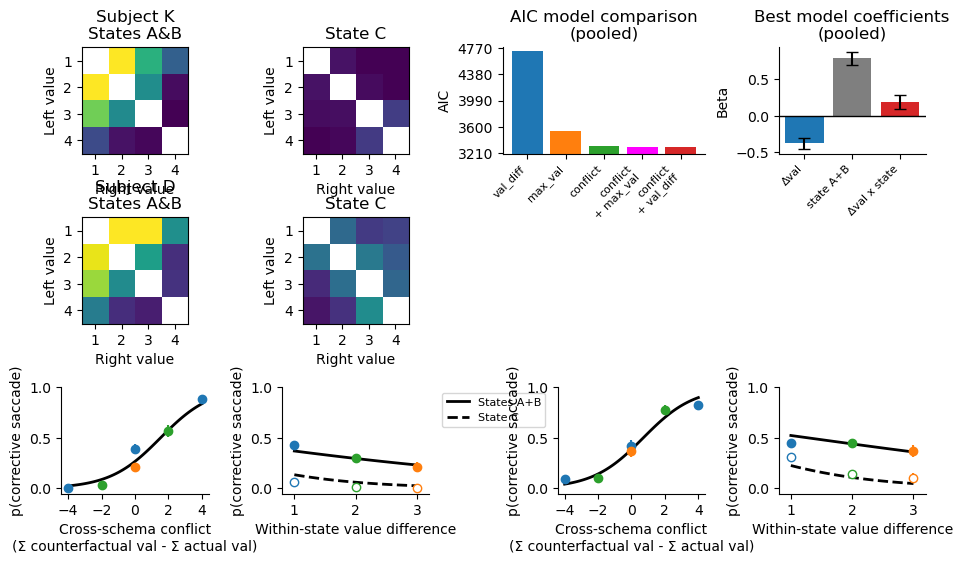

In [50]:
fig = plt.figure(figsize=(14, 8))
gs = gridspec.GridSpec(4, 20, figure=fig, hspace=0.6, wspace=0.5)

# heatmaps - subject K (row 0)
K_heatmap_AB_ax = fig.add_subplot(gs[0, 0:3])
K_heatmap_C_ax  = fig.add_subplot(gs[0, 4:7])
# AIC and beta weights - pooled, row 0 only, next to K heatmaps
aic_ax          = fig.add_subplot(gs[0, 8:12])
beta_ax         = fig.add_subplot(gs[0, 13:16])
# heatmaps - subject D (row 1)
D_heatmap_AB_ax = fig.add_subplot(gs[1, 0:3])
D_heatmap_C_ax  = fig.add_subplot(gs[1, 4:7])

# regression plots 
K_reg_conf_ax   = fig.add_subplot(gs[2, 0:3])
K_reg_val_ax    = fig.add_subplot(gs[2, 4:7])
D_reg_conf_ax   = fig.add_subplot(gs[2, 9:12])
D_reg_val_ax    = fig.add_subplot(gs[2, 13:16])

# --- heatmaps ---
p_min, p_max = 0, 0.8

K_heatmap_AB_ax.imshow(pDT_by_val_and_state[:,:,0,0], aspect='equal', vmin=p_min, vmax=p_max)
K_heatmap_AB_ax.set_xticks(range(4)); K_heatmap_AB_ax.set_xticklabels([1,2,3,4])
K_heatmap_AB_ax.set_yticks(range(4)); K_heatmap_AB_ax.set_yticklabels([1,2,3,4])
K_heatmap_AB_ax.set_title('Subject K\nStates A&B')
K_heatmap_AB_ax.set_xlabel('Right value')
K_heatmap_AB_ax.set_ylabel('Left value')

K_heatmap_C_ax.imshow(pDT_by_val_and_state[:,:,1,0], aspect='equal', vmin=p_min, vmax=p_max)
K_heatmap_C_ax.set_xticks(range(4)); K_heatmap_C_ax.set_xticklabels([1,2,3,4])
K_heatmap_C_ax.set_yticks(range(4)); K_heatmap_C_ax.set_yticklabels([1,2,3,4])
K_heatmap_C_ax.set_title('State C')
K_heatmap_C_ax.set_xlabel('Right value')
K_heatmap_C_ax.set_ylabel('Left value')

D_heatmap_AB_ax.imshow(pDT_by_val_and_state[:,:,0,1], aspect='equal', vmin=p_min, vmax=p_max)
D_heatmap_AB_ax.set_xticks(range(4)); D_heatmap_AB_ax.set_xticklabels([1,2,3,4])
D_heatmap_AB_ax.set_yticks(range(4)); D_heatmap_AB_ax.set_yticklabels([1,2,3,4])
D_heatmap_AB_ax.set_title('Subject D\nStates A&B')
D_heatmap_AB_ax.set_xlabel('Right value')
D_heatmap_AB_ax.set_ylabel('Left value')

D_heatmap_C_ax.imshow(pDT_by_val_and_state[:,:,1,1], aspect='equal', vmin=p_min, vmax=p_max)
D_heatmap_C_ax.set_xticks(range(4)); D_heatmap_C_ax.set_xticklabels([1,2,3,4])
D_heatmap_C_ax.set_yticks(range(4)); D_heatmap_C_ax.set_yticklabels([1,2,3,4])
D_heatmap_C_ax.set_title('State C')
D_heatmap_C_ax.set_xlabel('Right value')
D_heatmap_C_ax.set_ylabel('Left value')

# --- AIC plot (pooled, panel D) ---
model_labels_aic = list(formulas.keys())
colors_aic = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'magenta']
vals_aic = [aics[label] for label in model_labels_aic]
order_aic = np.argsort(vals_aic)[::-1]
sorted_labels_aic = [model_labels_aic[j] for j in order_aic]
sorted_vals_aic = [vals_aic[j] for j in order_aic]
sorted_colors_aic = [colors_aic[j] for j in order_aic]

aic_ax.bar(sorted_labels_aic, sorted_vals_aic, color=sorted_colors_aic)
ymin = min(sorted_vals_aic) * 0.97
ymax = max(sorted_vals_aic) * 1.01
tick_min = int(np.ceil(ymin / 10) * 10)
tick_max = int(np.floor(ymax / 10) * 10)
aic_ax.set_yticks(np.round(np.linspace(tick_min, tick_max, 5) / 10) * 10)
aic_ax.set_ylim(ymin, ymax)
aic_ax.set_title('AIC model comparison\n(pooled)')
aic_ax.set_ylabel('AIC')
aic_ax.set_xticks(range(len(sorted_labels_aic)))
aic_ax.set_xticklabels(sorted_labels_aic, rotation=45, ha='right', fontsize=8)
aic_ax.spines['right'].set_visible(False)
aic_ax.spines['top'].set_visible(False)

# --- beta weights (pooled, panel E) ---
terms = ['val_diff_z', 'state_AB_z', 'val_diff_z:state_AB_z']
term_labels = ['Δval', 'state A+B', 'Δval x state']
beta_colors = ['tab:blue', 'tab:gray', 'tab:red']

coefs = [model_partb.params[t] for t in terms]
ci_low = [model_partb.conf_int().loc[t, 0] for t in terms]
ci_high = [model_partb.conf_int().loc[t, 1] for t in terms]
yerr_low = [coefs[i] - ci_low[i] for i in range(len(terms))]
yerr_high = [ci_high[i] - coefs[i] for i in range(len(terms))]

beta_ax.bar(term_labels, coefs, color=beta_colors)
beta_ax.errorbar(term_labels, coefs,
                 yerr=[yerr_low, yerr_high],
                 fmt='none', color='black', capsize=4)
beta_ax.axhline(0, color='k', lw=1)
beta_ax.set_ylabel('Beta')
beta_ax.set_title('Best model coefficients\n(pooled)')
beta_ax.set_xticklabels(term_labels, rotation=45, ha='right', fontsize=8)
beta_ax.spines['right'].set_visible(False)
beta_ax.spines['top'].set_visible(False)

# --- regression plots ---
# precompute means for prediction
val_diff_mean = data_all['real_val_diff'].mean()
val_diff_std  = data_all['real_val_diff'].std()
mean_state_AB_z_AB = data_all.loc[stateAB_ix, 'state_AB_z'].mean()
mean_state_AB_z_C  = data_all.loc[stateC_ix,  'state_AB_z'].mean()

conflict_sum_fine = np.linspace(-4, 4, 100)
val_diff_fine = np.linspace(1, 3, 100)
val_diff_fine_z = (val_diff_fine - val_diff_mean) / val_diff_std

for subj, k_or_d, conf_ax, val_ax in zip(
    ['K', 'D'],
    [k_ix_reg, d_ix_reg],
    [K_reg_conf_ax, D_reg_conf_ax],
    [K_reg_val_ax, D_reg_val_ax]
):
    AB_df = reg_df.loc[k_or_d & stateAB_ix]

    # conflict panel - observed data
    for val_diff, color in zip(val_diff_levels, diff_colors):
        for conf in conflict_sum_levels:
            mask = (AB_df['real_val_diff'] == val_diff) & (AB_df['conflict_sum'] == conf)
            if mask.sum() < 3:
                continue
            m, ci = calculate_mean_and_interval(AB_df.loc[mask, 'corrective_sacc'].values.reshape(-1,1), 'bootstrap')
            conf_ax.errorbar(conf, m, ci, color=color, marker='o', ms=6, lw=0, elinewidth=1.5)

    # conflict panel - model fit from models_a best model
    pred_conf_df = pd.DataFrame({
        'real_val_diff': np.full(100, np.mean(val_diff_levels)),
        'conflict_sum': conflict_sum_fine,
        'subject': subj
    })
    conf_ax.plot(conflict_sum_fine, models['conflict\n+ val_diff'].predict(pred_conf_df), color='k', lw=2)
    conf_ax.set_xlabel('Cross-schema conflict\n(Σ counterfactual val - Σ actual val)')
    conf_ax.set_ylabel('p(corrective saccade)')
    conf_ax.set_ylim(-0.05, 1)
    conf_ax.set_xticks([-4, -2, 0, 2, 4])
    conf_ax.spines['right'].set_visible(False)
    conf_ax.spines['top'].set_visible(False)

    # val diff panel - observed data
    for state, filled in [(1, True), (-1, False)]:
        state_df = reg_df.loc[k_or_d & (reg_df['state_AB'] == state)]
        for val_diff, color in zip(val_diff_levels, diff_colors):
            mask = state_df['real_val_diff'] == val_diff
            if mask.sum() < 3:
                continue
            m, ci = calculate_mean_and_interval(state_df.loc[mask, 'corrective_sacc'].values.reshape(-1,1), 'bootstrap')
            val_ax.errorbar(val_diff, m, ci, color=color, marker='o', ms=6, lw=0, elinewidth=1.5,
                            markerfacecolor=color if filled else 'white', markeredgecolor=color)

    # val diff panel - model fit from model_partb
    pred_AB = pd.DataFrame({
        'val_diff_z': val_diff_fine_z,
        'state_AB_z': np.full(100, mean_state_AB_z_AB),
        'subject': subj
    })
    pred_C = pd.DataFrame({
        'val_diff_z': val_diff_fine_z,
        'state_AB_z': np.full(100, mean_state_AB_z_C),
        'subject': subj
    })
    val_ax.plot(val_diff_fine, model_partb.predict(pred_AB), color='k', lw=2, label='States A+B')
    val_ax.plot(val_diff_fine, model_partb.predict(pred_C), color='k', lw=2, ls='--', label='State C')
    val_ax.set_xlabel('Within-state value difference')
    val_ax.set_ylabel('p(corrective saccade)')
    val_ax.set_ylim(-0.05, 1)
    val_ax.set_xlim(0.8, 3.2)
    val_ax.spines['right'].set_visible(False)
    val_ax.spines['top'].set_visible(False)
    if subj == 'K':
        val_ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

In [ ]:
# fit RT models with subject as random effect (ML not REML for AIC comparison)
rt_formulas = {
    'val_diff':             'rt ~ real_val_diff',
    'max_val':              'rt ~ max_val',
    'conflict':             'rt ~ conflict_sum',
    'conflict\n+ val_diff': 'rt ~ conflict_sum + real_val_diff',
    'conflict\n+ max_val':  'rt ~ conflict_sum + max_val',
}

val_diff_levels = [1, 2, 3]
diff_colors = ['tab:blue', 'tab:green', 'tab:orange']

# prepare stateAB data for model comparison
data_stateAB_rt = reg_df.loc[stateAB_ix, ['rt', 'real_val_diff', 'conflict_sum', 'max_val', 'subject']].dropna().copy().reset_index(drop=True)

rt_models = {}
rt_aics = {}
for label, formula in rt_formulas.items():
    model = smf.mixedlm(formula, data=data_stateAB_rt, groups=data_stateAB_rt['subject'].values).fit(reml=False)
    rt_models[label] = model
    rt_aics[label] = model.aic

# prepare all states data for interaction model
data_all_rt = reg_df.loc[free_ix, ['rt', 'real_val_diff', 'state_AB', 'subject']].dropna().copy().reset_index(drop=True)

# standardize using data_all_rt's own mean and std
val_diff_mean_rt = data_all_rt['real_val_diff'].mean()
val_diff_std_rt  = data_all_rt['real_val_diff'].std()
data_all_rt['val_diff_z'] = (data_all_rt['real_val_diff'] - val_diff_mean_rt) / val_diff_std_rt
data_all_rt['state_AB_z'] = (data_all_rt['state_AB'] - data_all_rt['state_AB'].mean()) / data_all_rt['state_AB'].std()

# precompute state-specific means of state_AB_z for prediction
mean_state_AB_z_AB_rt = data_all_rt.loc[data_all_rt['state_AB'] == 1,  'state_AB_z'].mean()
mean_state_AB_z_C_rt  = data_all_rt.loc[data_all_rt['state_AB'] == -1, 'state_AB_z'].mean()

rt_model_b = smf.mixedlm(
    'rt ~ val_diff_z * state_AB_z',
    data=data_all_rt,
    groups=data_all_rt['subject'].values
).fit()

print('RT model comparison AICs:')
print(pd.DataFrame({'AIC': rt_aics}))
print('\nRT interaction model:')
print(rt_model_b.summary())

# best model for conflict panel
best_rt_model_label = min(rt_aics, key=rt_aics.get)
print(f'\nBest RT model: {best_rt_model_label}')

# fine grids for prediction
conflict_sum_fine = np.linspace(-4, 4, 100)
val_diff_fine     = np.linspace(1, 3, 100)
val_diff_fine_z   = (val_diff_fine - val_diff_mean_rt) / val_diff_std_rt
mean_val_diff_rt  = data_stateAB_rt['real_val_diff'].mean()

# --- figure ---
fig = plt.figure(figsize=(14, 8))
gs = gridspec.GridSpec(2, 20, figure=fig, hspace=0.6, wspace=0.5)

# top row - AIC and beta only
aic_ax  = fig.add_subplot(gs[0, 0:4])
beta_ax = fig.add_subplot(gs[0, 5:8])

# bottom row - regression plots
K_rt_conf_ax = fig.add_subplot(gs[1, 0:5])
K_rt_val_ax  = fig.add_subplot(gs[1, 6:8])
D_rt_conf_ax = fig.add_subplot(gs[1, 10:15])
D_rt_val_ax  = fig.add_subplot(gs[1, 16:18])

# --- AIC plot ---
rt_model_labels = list(rt_formulas.keys())
colors_aic = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'magenta']
vals_aic = [rt_aics[label] for label in rt_model_labels]
order_aic = np.argsort(vals_aic)[::-1]
sorted_labels_aic = [rt_model_labels[j] for j in order_aic]
sorted_vals_aic   = [vals_aic[j] for j in order_aic]
sorted_colors_aic = [colors_aic[j] for j in order_aic]

aic_ax.bar(sorted_labels_aic, sorted_vals_aic, color=sorted_colors_aic)
ymin = min(sorted_vals_aic) * 0.97
ymax = max(sorted_vals_aic) * 1.01
tick_min = int(np.ceil(ymin / 10) * 10)
tick_max = int(np.floor(ymax / 10) * 10)
aic_ax.set_yticks(np.round(np.linspace(tick_min, tick_max, 5) / 10) * 10)
aic_ax.set_ylim(ymin, ymax)
aic_ax.set_title('AIC model comparison\n(pooled)')
aic_ax.set_ylabel('AIC')
aic_ax.set_xticks(range(len(sorted_labels_aic)))
aic_ax.set_xticklabels(sorted_labels_aic, rotation=45, ha='right', fontsize=8)
aic_ax.spines['right'].set_visible(False)
aic_ax.spines['top'].set_visible(False)

# --- beta weights ---
terms = ['val_diff_z', 'state_AB_z', 'val_diff_z:state_AB_z']
term_labels = ['Δval', 'state A+B', 'Δval x state']
beta_colors_plot = ['tab:blue', 'tab:gray', 'tab:red']

coefs   = [rt_model_b.params[t] for t in terms]
ci_low  = [rt_model_b.conf_int().loc[t, 0] for t in terms]
ci_high = [rt_model_b.conf_int().loc[t, 1] for t in terms]
yerr_low  = [coefs[i] - ci_low[i]  for i in range(len(terms))]
yerr_high = [ci_high[i] - coefs[i] for i in range(len(terms))]

beta_ax.bar(term_labels, coefs, color=beta_colors_plot)
beta_ax.errorbar(term_labels, coefs,
                 yerr=[yerr_low, yerr_high],
                 fmt='none', color='black', capsize=4)
beta_ax.axhline(0, color='k', lw=1)
beta_ax.set_ylabel('Beta (ms)')
beta_ax.set_title('Interaction model\ncoefficients (pooled)')
beta_ax.set_xticklabels(term_labels, rotation=45, ha='right', fontsize=8)
beta_ax.spines['right'].set_visible(False)
beta_ax.spines['top'].set_visible(False)

# --- regression plots ---
for subj, k_or_d, conf_ax, val_ax in zip(
    ['K', 'D'],
    [k_ix_reg, d_ix_reg],
    [K_rt_conf_ax, D_rt_conf_ax],
    [K_rt_val_ax,  D_rt_val_ax]
):
    AB_df = reg_df.loc[k_or_d & stateAB_ix]

    # conflict panel - observed data
    for val_diff, color in zip(val_diff_levels, diff_colors):
        for conf in conflict_sum_levels:
            mask = (AB_df['real_val_diff'] == val_diff) & (AB_df['conflict_sum'] == conf) & AB_df['rt'].notna()
            if mask.sum() < 3:
                continue
            m, ci = calculate_mean_and_interval(AB_df.loc[mask, 'rt'].values.reshape(-1,1), 'bootstrap')
            conf_ax.errorbar(conf, m, ci, color=color, marker='o', ms=6, lw=0, elinewidth=1.5)

    # conflict panel - model fit
    pred_conf_df = pd.DataFrame({
        'real_val_diff': np.full(100, mean_val_diff_rt),
        'conflict_sum':  conflict_sum_fine,
        'max_val':       np.full(100, data_stateAB_rt['max_val'].mean()),
    })
    conf_ax.plot(conflict_sum_fine, rt_models[best_rt_model_label].predict(pred_conf_df), color='k', lw=2)
    conf_ax.set_xlabel('Cross-schema conflict\n(Σ counterfactual val - Σ actual val)')
    conf_ax.set_ylabel('RT (ms)')
    conf_ax.set_xticks([-4, -2, 0, 2, 4])
    conf_ax.set_ylim((90, 410))
    conf_ax.set_title(f'Subject {subj}')
    conf_ax.spines['right'].set_visible(False)
    conf_ax.spines['top'].set_visible(False)

    # val diff panel - observed data
    for state, filled in [(1, True), (-1, False)]:
        state_df = reg_df.loc[k_or_d & (reg_df['state_AB'] == state) & reg_df['rt'].notna()]
        for val_diff, color in zip(val_diff_levels, diff_colors):
            mask = state_df['real_val_diff'] == val_diff
            if mask.sum() < 3:
                continue
            m, ci = calculate_mean_and_interval(state_df.loc[mask, 'rt'].values.reshape(-1,1), 'bootstrap')
            val_ax.errorbar(val_diff, m, ci, color=color, marker='o', ms=6, lw=0, elinewidth=1.5,
                            markerfacecolor=color if filled else 'white', markeredgecolor=color)

    # val diff panel - model fit from rt_model_b
    pred_AB = pd.DataFrame({
        'val_diff_z': val_diff_fine_z,
        'state_AB_z': np.full(100, mean_state_AB_z_AB_rt),
    })
    pred_C = pd.DataFrame({
        'val_diff_z': val_diff_fine_z,
        'state_AB_z': np.full(100, mean_state_AB_z_C_rt),
    })
    val_ax.plot(val_diff_fine, rt_model_b.predict(pred_AB), color='k', lw=2, label='States A+B')
    val_ax.plot(val_diff_fine, rt_model_b.predict(pred_C), color='k', lw=2, ls='--', label='State C')
    val_ax.set_xlabel('Within-state value difference')
    val_ax.set_ylabel('RT (ms)')
    val_ax.set_xlim(0.8, 3.2)
    val_ax.set_ylim((90, 410))
    val_ax.set_title(f'Subject {subj}')
    val_ax.spines['right'].set_visible(False)
    val_ax.spines['top'].set_visible(False)
    if subj == 'K':
        val_ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

#plt.savefig('RTs-by-conflict.svg')